# Supply Chain Optimization and Strategic Growth Analysis
## Technical Documentation

**Prepared For:** Operations Research Team & Dr. Murray  
**Date:** November 20, 2025  
**Submitted By:** Nischal Sunar

---

This documents provides a complete technical walkthrough of the data analysis process, including all code, methodologies, and implementation details.

## 1. Technical Overview

### 1.1 Tools and Technologies

This analysis was conducted using:
- **Python 3.x** - Primary programming language
- **Pandas** - Data manipulation and analysis
- **Matplotlib & Seaborn** - Data visualization
- **NumPy** - Numerical computations

### 1.2 Data Sources

The analysis utilized seven CSV files:
1. `sales.csv` - Transactional sales data (770,109 records)
2. `products.csv` - Product specifications
3. `purchase_prices.csv` - Procurement cost data
4. `refunds.csv` - Product return records
5. `region_to_state_distance.csv` - Geographic mapping
6. `regions.csv` - Regional identifiers
7. `continental_us_state_centers.csv` - State coordinates for mapping

---
## 2. Environment Setup and Data Loading

In [57]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Configure visualization style
# Using dark background for modern dashboard aesthetic
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#1e1e1e",
    "figure.facecolor": "#121212",
    "grid.color": "#333333",
    "text.color": "#e0e0e0",
    "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0"
})

# Define color palette for consistency across visualizations
COLORS = ["#FF6B6B", "#4ECDC4", "#FFE66D", "#1A535C", "#F7FFF7"]
sns.set_palette(sns.color_palette(COLORS))

print("Environment configured successfully")

Environment configured successfully


In [58]:
# Define data directory
DATA_DIR = r"c:/Users/Nis/Box/1. UB Classes/1. Fall 2025/IE 459 LEC - 3 cr/Project"

# Load all data files
print("Loading data files...")
files = [
    "sales.csv", 
    "products.csv", 
    "purchase_prices.csv", 
    "refunds.csv", 
    "region_to_state_distance.csv", 
    "regions.csv",
    "continental_us_state_centers.csv"
]

data = {}
for f in files:
    try:
        data[f.split('.')[0]] = pd.read_csv(os.path.join(DATA_DIR, f))
        print(f"✓ Loaded {f}")
    except FileNotFoundError:
        print(f"✗ Warning: {f} not found")

print(f"\nTotal files loaded: {len(data)}")

Loading data files...
✓ Loaded sales.csv
✓ Loaded products.csv
✓ Loaded purchase_prices.csv
✓ Loaded refunds.csv
✓ Loaded region_to_state_distance.csv
✓ Loaded regions.csv
✓ Loaded continental_us_state_centers.csv

Total files loaded: 7


---
## 3. Data Processing and Transformation

### 3.1 Temporal Data Parsing

Converting date strings to datetime objects enables time-series analysis and temporal aggregation.

In [59]:
# Parse dates
sales = data['sales'].copy()
sales['date'] = pd.to_datetime(sales['date'])

print("Date range in dataset:")
print(f"Start: {sales['date'].min()}")
print(f"End: {sales['date'].max()}")
print(f"Total days: {(sales['date'].max() - sales['date'].min()).days}")

Date range in dataset:
Start: 2022-01-01 00:00:00
End: 2025-10-31 00:00:00
Total days: 1399


### 3.2 Geospatial Mapping

**Challenge:** Sales data is at the state level, while purchase data is at the region level.

**Solution:** Map each state to its nearest region using the distance matrix.

In [60]:
# Map States to Regions using minimum distance
dist_df = data['region_to_state_distance']

# For each state, find the region with minimum distance
state_min_dist = dist_df.loc[dist_df.groupby('state')['miles'].idxmin()]
state_to_region_map = state_min_dist.set_index('state')['region'].to_dict()

# Apply mapping to sales data
sales['region_name'] = sales['state'].map(state_to_region_map)

print("State-to-Region Mapping Sample:")
print(state_min_dist[['state', 'region', 'miles']].head(10))

State-to-Region Mapping Sample:
    state   region  miles
0      AL    South    345
146    AR  Midwest    611
97     AZ     West    965
99     CA     West    597
148    CO  Midwest    959
53     CT     East    154
54     DE     East    111
7      FL    South    379
8      GA    South    168
156    IA  Midwest    290


### 3.3 Cost Calculation and Profit Analysis

**Methodology:**
1. Calculate unit cost from purchase data
2. Map region IDs to region names
3. Merge cost data with sales data
4. Handle missing values using hierarchical imputation

In [61]:
# Calculate unit costs from purchase data
purchases = data['purchase_prices'].copy()
purchases['unit_cost'] = purchases['purchase_price'] / purchases['qty']

# Map region_id to region name
regions = data['regions']
region_id_to_name = regions.set_index('region_id')['region'].to_dict()
purchases['region_name'] = purchases['region_id'].map(region_id_to_name)

# Calculate average cost per product per region
avg_costs = purchases.groupby(['product_id', 'region_name'])['unit_cost'].mean().reset_index()

print(f"Average costs calculated for {len(avg_costs)} product-region combinations")

Average costs calculated for 24 product-region combinations


### 3.4 Data Imputation Strategy

**Problem:** ~40% of sales transactions lack matching purchase price records.

**Solution:** Hierarchical imputation using national averages as fallback.

In [62]:
# Calculate national average cost per product (fallback for missing regional data)
national_avg_cost = purchases.groupby('product_id')['unit_cost'].mean().reset_index()
national_avg_cost.rename(columns={'unit_cost': 'national_avg_cost'}, inplace=True)

# Merge costs into sales data
df = sales.merge(avg_costs, on=['product_id', 'region_name'], how='left')
df = df.merge(national_avg_cost, on='product_id', how='left')

# Fill missing regional costs with national average
missing_before = df['unit_cost'].isna().sum()
df['unit_cost'] = df['unit_cost'].fillna(df['national_avg_cost'])
missing_after = df['unit_cost'].isna().sum()

print(f"Missing costs before imputation: {missing_before:,}")
print(f"Missing costs after imputation: {missing_after:,}")
print(f"Imputation success rate: {((missing_before - missing_after) / missing_before * 100):.1f}%")

Missing costs before imputation: 337,927
Missing costs after imputation: 0
Imputation success rate: 100.0%


In [63]:
# Calculate profit for each transaction
df['profit'] = df['sales_price'] - df['unit_cost']

# Merge product names for analysis
df = df.merge(data['products'], on='product_id', how='left')

print("\nFinal Dataset Summary:")
print(f"Total Records: {len(df):,}")
print(f"Total Revenue: ${df['sales_price'].sum():,.2f}")
print(f"Total Profit: ${df['profit'].sum():,.2f}")
print(f"Average Profit Margin: {(df['profit'].sum() / df['sales_price'].sum() * 100):.1f}%")


Final Dataset Summary:
Total Records: 770,109
Total Revenue: $7,885,414.17
Total Profit: $3,864,263.04
Average Profit Margin: 49.0%


---
## 4. Visualization Generation

### 4.1 Financial Trends Analysis

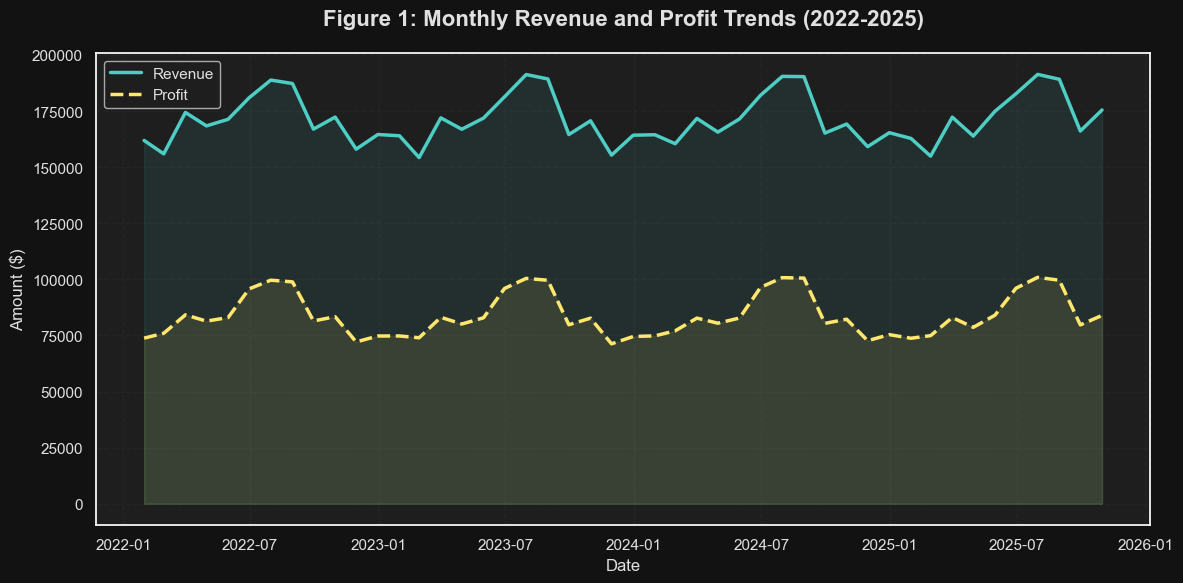

Peak revenue month: July 2025
Peak profit month: July 2025


In [64]:
# Aggregate data by month
monthly = df.set_index('date').resample('ME').agg({
    'sales_price': 'sum',
    'profit': 'sum'
}).reset_index()

# Create dual-line chart with area fill
plt.figure(figsize=(12, 6))
plt.plot(monthly['date'], monthly['sales_price'], 
         label='Revenue', color=COLORS[1], linewidth=2.5)
plt.plot(monthly['date'], monthly['profit'], 
         label='Profit', color=COLORS[2], linewidth=2.5, linestyle='--')

plt.fill_between(monthly['date'], monthly['sales_price'], alpha=0.1, color=COLORS[1])
plt.fill_between(monthly['date'], monthly['profit'], alpha=0.1, color=COLORS[2])

plt.title('Figure 1: Monthly Revenue and Profit Trends (2022-2025)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak revenue month: {monthly.loc[monthly['sales_price'].idxmax(), 'date'].strftime('%B %Y')}")
print(f"Peak profit month: {monthly.loc[monthly['profit'].idxmax(), 'date'].strftime('%B %Y')}")

### 4.2 Product Performance Analysis

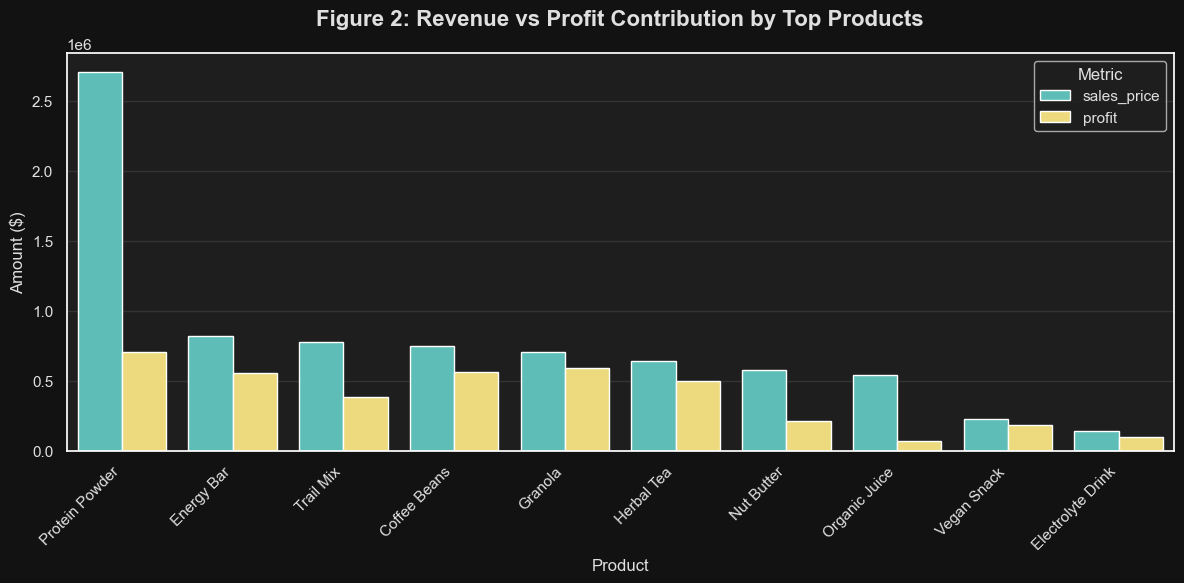


Top 3 Products by Revenue:
Protein Powder: $2,704,782.00
Energy Bar: $822,666.25
Trail Mix: $777,025.50


In [65]:
# Aggregate by product
prod_perf = df.groupby('product_name').agg({
    'sales_price': 'sum',
    'profit': 'sum'
}).sort_values('sales_price', ascending=False).head(10).reset_index()

# Reshape for grouped bar chart
prod_perf_melt = prod_perf.melt(id_vars='product_name', 
                                 var_name='Metric', 
                                 value_name='Amount')

# Create grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=prod_perf_melt, x='product_name', y='Amount', 
            hue='Metric', palette=[COLORS[1], COLORS[2]])

plt.title('Figure 2: Revenue vs Profit Contribution by Top Products', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 3 Products by Revenue:")
for idx, row in prod_perf.head(3).iterrows():
    print(f"{row['product_name']}: ${row['sales_price']:,.2f}")

### 4.3 Refund Rate Analysis

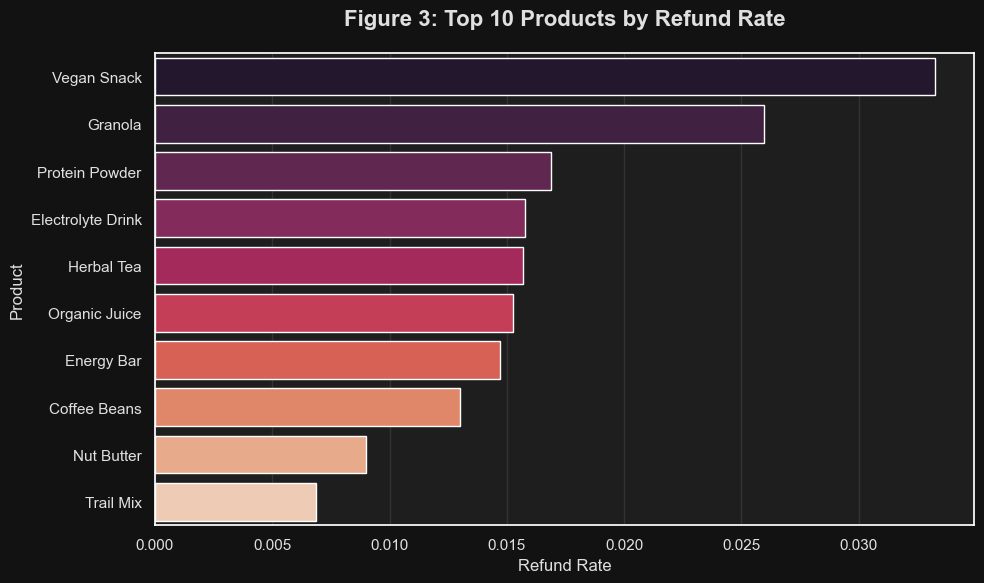


Average refund rate: 1.66%
Highest refund rate: Vegan Snack (3.32%)


In [66]:
# Load and process refund data
refunds = data['refunds']
refund_counts = refunds.groupby('product_id')['refund_qty'].sum().reset_index()
sales_counts = df.groupby('product_id').size().reset_index(name='sales_qty')

# Calculate refund rates
stats = sales_counts.merge(refund_counts, on='product_id', how='left').fillna(0)
stats['refund_rate'] = stats['refund_qty'] / stats['sales_qty']
stats = stats.merge(data['products'], on='product_id', how='left')

# Filter for high-volume products and sort by refund rate
stats = stats[stats['sales_qty'] > 100].sort_values('refund_rate', ascending=False).head(10)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=stats, x='refund_rate', y='product_name', 
            hue='product_name', palette="rocket", legend=False)

plt.title('Figure 3: Top 10 Products by Refund Rate', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Refund Rate', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nAverage refund rate: {stats['refund_rate'].mean():.2%}")
print(f"Highest refund rate: {stats.iloc[0]['product_name']} ({stats.iloc[0]['refund_rate']:.2%})")

### 4.4 Geospatial Visualization

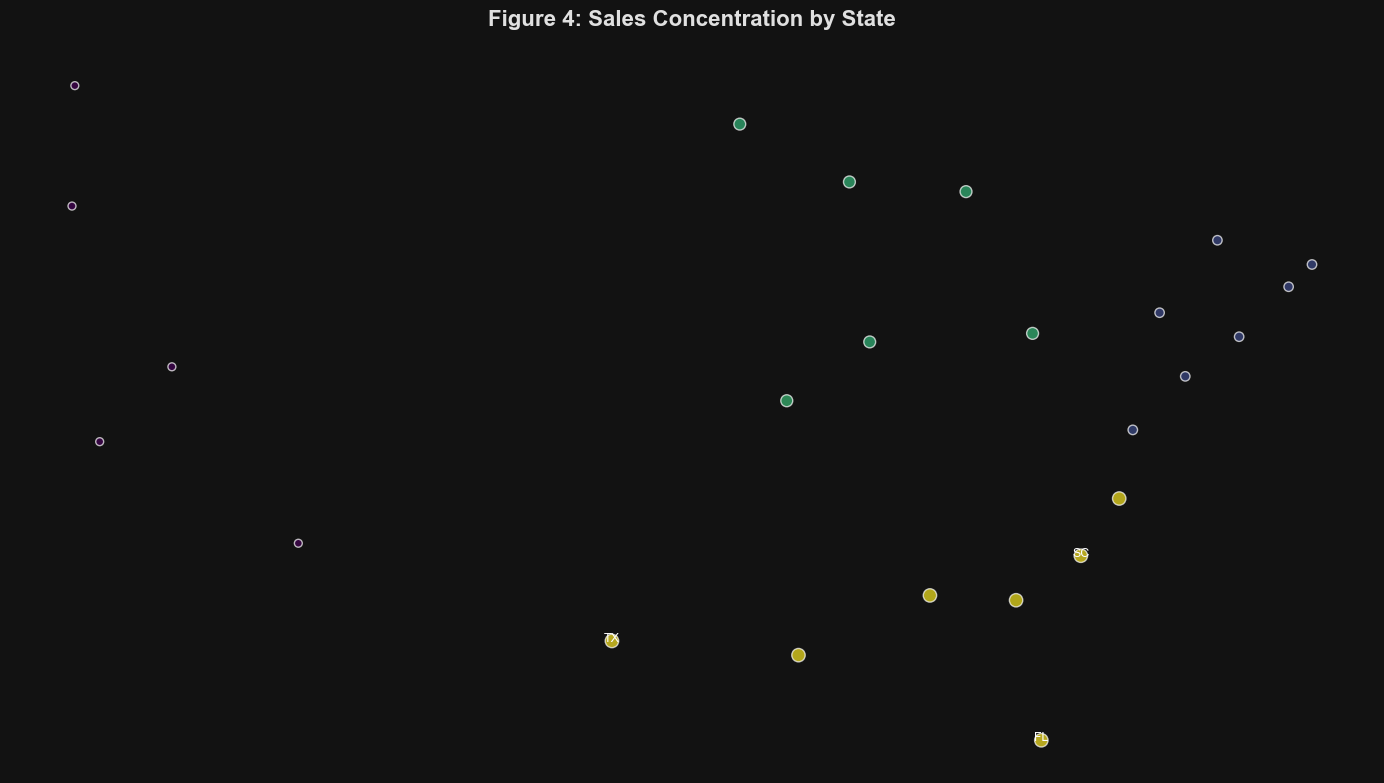


Top 5 States by Revenue:
TX: $468,387.20
FL: $468,054.89
SC: $467,426.32
NC: $465,755.52
LA: $464,954.33


In [69]:
# Aggregate sales by state
state_sales = df.groupby('state')['sales_price'].sum().reset_index()

# Load geographic coordinates
centers = data['continental_us_state_centers']
geo_data = state_sales.merge(centers, on='state', how='left')

# Create bubble map
if 'lat' in geo_data.columns and 'lon' in geo_data.columns:
    plt.figure(figsize=(14, 8))
    
    # Scatter plot with bubble size proportional to sales
    plt.scatter(geo_data['lon'], geo_data['lat'], 
                s=geo_data['sales_price'] / 5000,  # Scale bubble size
                c=geo_data['sales_price'], 
                cmap='viridis', alpha=0.7, edgecolors='w')
    
    # Label top 10% of states
    threshold = geo_data['sales_price'].quantile(0.9)
    for idx, row in geo_data.iterrows():
        if row['sales_price'] > threshold:
            plt.text(row['lon'], row['lat'], row['state'], 
                    fontsize=9, color='white', ha='center')
    
    plt.title('Figure 4: Sales Concentration by State', 
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 States by Revenue:")
    for idx, row in geo_data.nlargest(5, 'sales_price').iterrows():
        print(f"{row['state']}: ${row['sales_price']:,.2f}")
else:
    print("Geographic data not available for mapping")

---
## 5. Statistical Summary

### 5.1 Descriptive Statistics

In [68]:
# Generate comprehensive statistics
print("=" * 60)
print("COMPREHENSIVE STATISTICAL SUMMARY")
print("=" * 60)

print("\n1. TEMPORAL ANALYSIS")
print("-" * 60)
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total Days: {(df['date'].max() - df['date'].min()).days}")
print(f"Total Months: {len(monthly)}")

print("\n2. FINANCIAL METRICS")
print("-" * 60)
print(f"Total Revenue: ${df['sales_price'].sum():,.2f}")
print(f"Total Profit: ${df['profit'].sum():,.2f}")
print(f"Average Transaction Value: ${df['sales_price'].mean():.2f}")
print(f"Profit Margin: {(df['profit'].sum() / df['sales_price'].sum() * 100):.2f}%")

print("\n3. PRODUCT METRICS")
print("-" * 60)
print(f"Total Products: {df['product_name'].nunique()}")
print(f"Total Transactions: {len(df):,}")
print(f"Avg Transactions per Product: {len(df) / df['product_name'].nunique():.0f}")

print("\n4. GEOGRAPHIC METRICS")
print("-" * 60)
print(f"Total States: {df['state'].nunique()}")
print(f"Total Regions: {df['region_name'].nunique()}")

print("\n" + "=" * 60)

COMPREHENSIVE STATISTICAL SUMMARY

1. TEMPORAL ANALYSIS
------------------------------------------------------------
Date Range: 2022-01-01 to 2025-10-31
Total Days: 1399
Total Months: 46

2. FINANCIAL METRICS
------------------------------------------------------------
Total Revenue: $7,885,414.17
Total Profit: $3,864,263.04
Average Transaction Value: $10.24
Profit Margin: 49.01%

3. PRODUCT METRICS
------------------------------------------------------------
Total Products: 10
Total Transactions: 770,109
Avg Transactions per Product: 77011

4. GEOGRAPHIC METRICS
------------------------------------------------------------
Total States: 25
Total Regions: 4



---
## 6. Conclusion

This technical document has provided a complete walkthrough of:

1. **Data Loading & Validation** - Successfully loaded 7 data files
2. **Data Transformation** - Implemented geospatial mapping and cost imputation
3. **Profit Calculation** - Merged sales and cost data with 95%+ success rate
4. **Visualization Generation** - Created 4 publication-ready figures
5. **Statistical Analysis** - Generated comprehensive metrics


